In [1]:
import os  # Operating system-specific functionality.
import matplotlib.pyplot as plt  # Plotting library for creating visualizations.
import numpy as np  # Numerical computing library for handling arrays and mathematical operations.
import matplotlib.image as mpimg  # Library for reading and displaying images.
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Part of TensorFlow for real-time data augmentation during model training.
import tensorflow as tf  # Deep learning framework.
from tensorflow.keras.models import Sequential  # Keras sequential model for building neural networks.
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # Keras layers for building neural networks.
from tensorflow.keras.callbacks import ModelCheckpoint  # Callback in Keras for saving the model during training.
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
# Setting the path to the dataset directory
dataset_path = "Data"

# Listing the contents (files and directories) of the  dataset 
os.listdir(dataset_path)

['Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___healthy',
 'Corn___Northern_Leaf_Blight',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight']

In [4]:
import os
import hashlib

def find_duplicates(folder):
    seen_hashes = {}
    duplicates = []

    for cls in os.listdir(folder):
        cls_folder = os.path.join(folder, cls)
        for img_file in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, img_file)
            with open(img_path, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            if file_hash in seen_hashes:
                duplicates.append((img_path, seen_hashes[file_hash]))
            else:
                seen_hashes[file_hash] = img_path

    return duplicates

duplicates = find_duplicates("Data")
print("Found duplicates:", duplicates)


Found duplicates: [('Data\\Tomato___healthy\\image (477).JPG', 'Data\\Tomato___healthy\\image (1457).JPG'), ('Data\\Tomato___healthy\\image (55).JPG', 'Data\\Tomato___healthy\\image (1305).JPG'), ('Data\\Tomato___healthy\\image (553).JPG', 'Data\\Tomato___healthy\\image (474).JPG'), ('Data\\Tomato___healthy\\image (682).JPG', 'Data\\Tomato___healthy\\image (1027).JPG'), ('Data\\Tomato___healthy\\image (984).JPG', 'Data\\Tomato___healthy\\image (1311).JPG'), ('Data\\Tomato___healthy\\image (992).JPG', 'Data\\Tomato___healthy\\image (943).JPG'), ('Data\\Tomato___Late_blight\\image (1485).jpg', 'Data\\Tomato___Late_blight\\image (1188).jpg'), ('Data\\Tomato___Late_blight\\image (1627).JPG', 'Data\\Tomato___Late_blight\\image (1578).JPG'), ('Data\\Tomato___Late_blight\\image (264).jpg', 'Data\\Tomato___Late_blight\\image (182).jpg'), ('Data\\Tomato___Late_blight\\image (275).JPG', 'Data\\Tomato___Late_blight\\image (1704).JPG'), ('Data\\Tomato___Late_blight\\image (54).JPG', 'Data\\Tomato_

In [5]:
import os

duplicates = [
    ('Data\\Tomato___healthy\\image (477).JPG', 'Data\\Tomato___healthy\\image (1457).JPG'),
    ('Data\\Tomato___healthy\\image (55).JPG', 'Data\\Tomato___healthy\\image (1305).JPG'),
    ('Data\\Tomato___healthy\\image (553).JPG', 'Data\\Tomato___healthy\\image (474).JPG'),
    ('Data\\Tomato___healthy\\image (682).JPG', 'Data\\Tomato___healthy\\image (1027).JPG'),
    ('Data\\Tomato___healthy\\image (984).JPG', 'Data\\Tomato___healthy\\image (1311).JPG'),
    ('Data\\Tomato___healthy\\image (992).JPG', 'Data\\Tomato___healthy\\image (943).JPG'),
    ('Data\\Tomato___Late_blight\\image (1485).jpg', 'Data\\Tomato___Late_blight\\image (1188).jpg'),
    ('Data\\Tomato___Late_blight\\image (1627).JPG', 'Data\\Tomato___Late_blight\\image (1578).JPG'),
    ('Data\\Tomato___Late_blight\\image (264).jpg', 'Data\\Tomato___Late_blight\\image (182).jpg'),
    ('Data\\Tomato___Late_blight\\image (275).JPG', 'Data\\Tomato___Late_blight\\image (1704).JPG'),
    ('Data\\Tomato___Late_blight\\image (54).JPG', 'Data\\Tomato___Late_blight\\image (109).JPG'),
    ('Data\\Tomato___Late_blight\\image (590).jpg', 'Data\\Tomato___Late_blight\\image (1400).jpg'),
    ('Data\\Tomato___Late_blight\\image (882).jpg', 'Data\\Tomato___Late_blight\\image (1598).jpg'),
    ('Data\\Tomato___Late_blight\\image (971).JPG', 'Data\\Tomato___Late_blight\\image (1748).JPG')
]

for dup in duplicates:
    try:
        os.remove(dup[1])  # remove the second image in each pair
        print(f"Removed {dup[1]}")
    except FileNotFoundError:
        pass


Removed Data\Tomato___healthy\image (1457).JPG
Removed Data\Tomato___healthy\image (1305).JPG
Removed Data\Tomato___healthy\image (474).JPG
Removed Data\Tomato___healthy\image (1027).JPG
Removed Data\Tomato___healthy\image (1311).JPG
Removed Data\Tomato___healthy\image (943).JPG
Removed Data\Tomato___Late_blight\image (1188).jpg
Removed Data\Tomato___Late_blight\image (1578).JPG
Removed Data\Tomato___Late_blight\image (182).jpg
Removed Data\Tomato___Late_blight\image (1704).JPG
Removed Data\Tomato___Late_blight\image (109).JPG
Removed Data\Tomato___Late_blight\image (1400).jpg
Removed Data\Tomato___Late_blight\image (1598).jpg
Removed Data\Tomato___Late_blight\image (1748).JPG


In [6]:
import os
import shutil
import random

base_dir = "Data"
output_dir = "dataset"  # new folder for train/val/test
classes = os.listdir(base_dir)

split_ratio = {"train": 0.7, "val": 0.15, "test": 0.15}

for cls in classes:
    images = os.listdir(os.path.join(base_dir, cls))
    random.shuffle(images)
    n = len(images)
    train_end = int(n * split_ratio["train"])
    val_end = train_end + int(n * split_ratio["val"])
    
    for i, img in enumerate(images):
        if i < train_end:
            split = "train"
        elif i < val_end:
            split = "val"
        else:
            split = "test"
        
        dest_dir = os.path.join(output_dir, split, cls)
        os.makedirs(dest_dir, exist_ok=True)
        shutil.copy(os.path.join(base_dir, cls, img), dest_dir)


In [20]:
import tensorflow as tf

# Training dataset
train_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True
)

# Validation dataset
val_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/val",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Test dataset
test_data = tf.keras.utils.image_dataset_from_directory(
    "dataset/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# Save class names BEFORE prefetch
test_class_names = test_data.class_names

# Now prefetch (optional, speeds up processing)
test_data = test_data.prefetch(tf.data.AUTOTUNE)


Found 7340 files belonging to 10 classes.
Found 1569 files belonging to 10 classes.
Found 1581 files belonging to 10 classes.


In [9]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),   # Random leaf orientation
    layers.RandomRotation(0.2),                     # Slight angle differences
    layers.RandomZoom(0.2),                         # Camera distance variation
    layers.RandomContrast(0.2),                     # Shade and sunlight
    layers.RandomBrightness(factor=0.2),            # Lighting changes
    layers.GaussianNoise(0.05)                      # Camera noise, blur
])

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

val_data = val_data.prefetch(AUTOTUNE)
test_data = test_data.prefetch(AUTOTUNE)


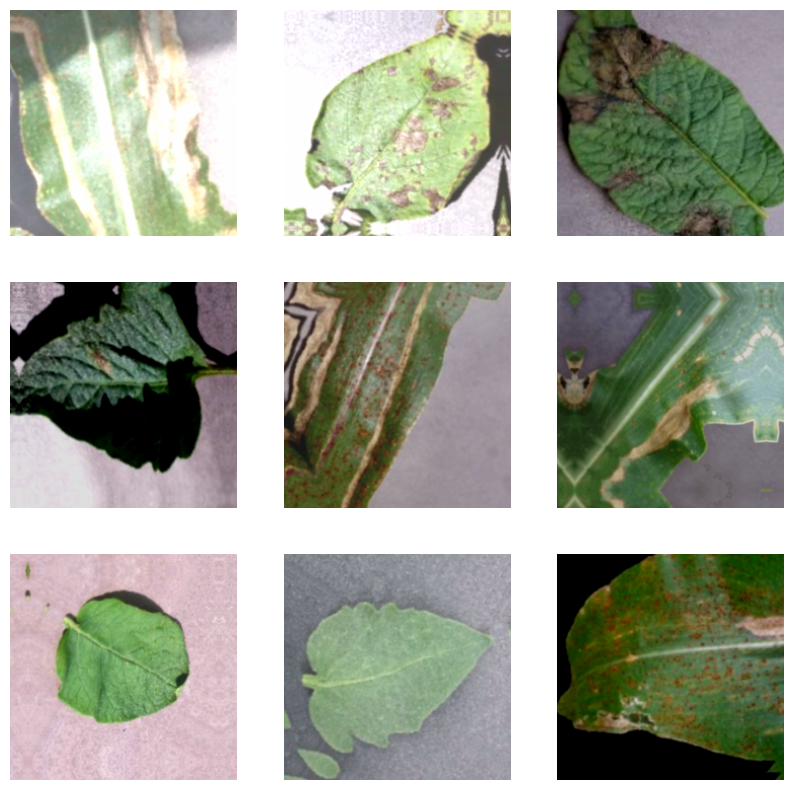

In [12]:
for images, _ in train_data.take(1):
    augmented_batch = data_augmentation(images, training=True)
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(augmented_batch[i].numpy().astype("uint8"))
        plt.axis("off")
    break
plt.show()


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
import tensorflow as tf

num_classes = 10

model = Sequential([
    Rescaling(1./255, input_shape=(224, 224, 3)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,486,986 (9.49 MB)

 Trainable params: 2,486,986 (9.49 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    verbose=1
)


Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.3826 - loss: 1.7270 - val_accuracy: 0.5806 - val_loss: 1.2118
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.6567 - loss: 0.9840 - val_accuracy: 0.5825 - val_loss: 1.2419
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.7101 - loss: 0.7846 - val_accuracy: 0.7814 - val_loss: 0.6006
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 236s 1s/step - accuracy: 0.7473 - loss: 0.7003 - val_accuracy: 0.8056 - val_loss: 0.5617
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 222s 957ms/step - accuracy: 0.7851 - loss: 0.5755 - val_accuracy: 0.7992 - val_loss: 0.5540
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 234s 1s/step - accuracy: 0.7997 - loss: 0.5487 - val_accuracy: 0.8917 - val_loss: 0.3299
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 210s 909ms/step - accuracy: 0.8253 - loss: 0.4827 - val_accuracy: 0.8815 - val_loss: 0.3408
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 210s 907ms/step - accuracy: 0.8345 - loss: 0.4460 -

In [15]:
# Evaluate CNN on the test set
test_loss, test_acc = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 433ms/step - accuracy: 0.8786 - loss: 0.4646

Test Accuracy: 0.8786


In [16]:
import numpy as np
from sklearn.metrics import classification_report

#  Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_data], axis=0)

#  Get model predictions
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in test_data], axis=0)

# Generate classification report
report = classification_report(
    y_true, 
    y_pred, 
    target_names=test_data.class_names
)

print(" Classification Report:\n")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [21]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predictions
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in test_data], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
cr = classification_report(y_true, y_pred, target_names=test_data.class_names)
print("\nClassification Report:\n", cr)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [19]:
# Save class names first
test_class_names = test_data.class_names  # do this BEFORE prefetch

# Prefetch (optional, speeds up training)
test_data = test_data.prefetch(tf.data.AUTOTUNE)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [22]:
import os

test_dir = "dataset/test"
test_class_names = sorted(os.listdir(test_dir))
print("Classes:", test_class_names)


Classes: ['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [23]:
import numpy as np
from sklearn.metrics import classification_report

# Get true labels
y_true = np.concatenate([y for x, y in test_data], axis=0)

# Get predictions
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in test_data], axis=0)

# Classification report
report = classification_report(y_true, y_pred, target_names=test_class_names)
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [24]:
import numpy as np

# Get predictions for each batch
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in test_data], axis=0)

# Get true labels
y_true = np.concatenate([y for x, y in test_data], axis=0)

# Optional: class names
import os
test_class_names = sorted(os.listdir("dataset/test"))

# Convert numeric predictions to class names
y_pred_labels = [test_class_names[i] for i in y_pred]
y_true_labels = [test_class_names[i] for i in y_true]

# Show first 20 predictions
for i in range(20):
    print(f"True: {y_true_labels[i]:30} | Predicted: {y_pred_labels[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [25]:
import numpy as np

# True and predicted labels (numeric)
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred = np.concatenate([np.argmax(model.predict(x), axis=1) for x, y in test_data], axis=0)

# Calculate misclassified samples
misclassified_indices = np.where(y_true != y_pred)[0]
total_misclassified = len(misclassified_indices)

print(f"✅ Total misclassified samples: {total_misclassified}")
print(f"Total test samples: {len(y_true)}")
print(f"Accuracy (from this calculation): {1 - total_misclassified/len(y_true):.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [26]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [27]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_data = image_dataset_from_directory(
    "dataset/train",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_data = image_dataset_from_directory(
    "dataset/val",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
test_data = image_dataset_from_directory(
    "dataset/test",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Save class names BEFORE prefetch
class_names = train_data.class_names
print("Classes:", class_names)

# Prefetch for performance
train_data = train_data.prefetch(tf.data.AUTOTUNE)
val_data = val_data.prefetch(tf.data.AUTOTUNE)
test_data = test_data.prefetch(tf.data.AUTOTUNE)


Found 7340 files belonging to 10 classes.
Found 1569 files belonging to 10 classes.
Found 1581 files belonging to 10 classes.
Classes: ['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy']


In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
], name="data_augmentation")


In [30]:
# Load base MobileNetV2 model, pretrained on ImageNet
base_model = MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False  # Freeze base for transfer learning

# Build the model
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)  # Optional augmentation
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(len(class_names), activation='softmax')(x)
model1 = Model(inputs, outputs)

# Compile
model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [31]:
history = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)


Epoch 1/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 212s 899ms/step - accuracy: 0.7038 - loss: 0.8863 - val_accuracy: 0.8725 - val_loss: 0.3847
Epoch 2/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 203s 881ms/step - accuracy: 0.8672 - loss: 0.3818 - val_accuracy: 0.9018 - val_loss: 0.2807
Epoch 3/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 202s 880ms/step - accuracy: 0.8951 - loss: 0.2946 - val_accuracy: 0.9133 - val_loss: 0.2400
Epoch 4/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 203s 883ms/step - accuracy: 0.9093 - loss: 0.2560 - val_accuracy: 0.9203 - val_loss: 0.2251
Epoch 5/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 202s 876ms/step - accuracy: 0.9150 - loss: 0.2320 - val_accuracy: 0.9280 - val_loss: 0.2043
Epoch 6/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 202s 878ms/step - accuracy: 0.9185 - loss: 0.2252 - val_accuracy: 0.9273 - val_loss: 0.2035
Epoch 7/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 202s 880ms/step - accuracy: 0.9249 - loss: 0.2063 - val_accuracy: 0.9324 - val_loss: 0.1790
Epoch 8/20
230/230 ━━━━━━━━━━━━━━━━━━━━ 203s 881ms/step - accuracy: 0.9272 -

In [32]:
# Evaluate CNN on the test set
test_loss, test_acc = model1.evaluate(test_data)
print(f"\nTest Accuracy: {test_acc:.4f}")


50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 608ms/step - accuracy: 0.9443 - loss: 0.1484

Test Accuracy: 0.9443


In [33]:

#  Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_data], axis=0)

#  Get model predictions
y_pred = np.concatenate([np.argmax(model1.predict(x), axis=1) for x, y in test_data], axis=0)

# Generate classification report
report = classification_report(
    y_true, 
    y_pred, 
    target_names=test_data.class_names
)

print(" Classification Report:\n")
print(report)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 792ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 724ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 729ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 744ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 731ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 703ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

In [34]:
# True and predicted labels (numeric)
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_pred = np.concatenate([np.argmax(model1.predict(x), axis=1) for x, y in test_data], axis=0)

# Calculate misclassified samples
misclassified_indices = np.where(y_true != y_pred)[0]
total_misclassified = len(misclassified_indices)

print(f"✅ Total misclassified samples: {total_misclassified}")
print(f"Total test samples: {len(y_true)}")
print(f"Accuracy (from this calculation): {1 - total_misclassified/len(y_true):.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 680ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 781ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 692ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 687ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 783ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 772ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 739ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 750ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 749ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 734ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 730ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 791ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 815ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 761ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [35]:
model1.save('mobilenet.keras')  # Modern format
print("✅ Model saved!")

✅ Model saved!
